In [1]:
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
run = ds.pipeline.open(label="docs_default")
clusters = run["clusters"]
markers = run["markers"]
cluster_values = np.asarray(run.cells.fetch("clusters"))

In [2]:
group_id = pd.Series(cluster_values).value_counts().index[0]
group_markers = ds.get_markers(
    marker=markers,
    group_id=group_id,
    min_score=-1,
    min_frac_exp=-1,
)
group_markers[
    [
        "feature_name",
        "score",
        "frac_exp",
        "fold_change",
        "auc",
        "p_value",
        "p_value_adjusted",
    ]
].head(12)

,feature_name,score,frac_exp,fold_change,auc,p_value,p_value_adjusted
0,ADTRP,0.57742,0.24194,13.33656,0.61061,6.964945e-111,1.283463e-108
1,ANKRD55,0.49898,0.14677,15.50163,0.56810,2.120385e-69,1.800341e-67
2,TSHZ2,0.47899,0.32903,6.40879,0.64016,1.265052e-123,2.702376e-121
3,TCEA3,0.46765,0.21613,8.13855,0.59343,7.444996e-81,8.133234e-79
4,CHRM3-AS2,0.44279,0.38065,7.00128,0.66191,1.764918e-143,4.851788e-141
5,FHIT,0.43108,0.62097,9.90167,0.77583,2.514596e-284,3.011947e-281
6,AC005842.1,0.43067,0.15887,7.74980,0.56916,1.204908e-60,8.114497e-59
7,EPHX2,0.42566,0.39435,6.96645,0.66579,6.171961e-143,1.669316e-140
8,CMTM8,0.42025,0.30645,4.82952,0.62029,2.656811e-87,3.453649e-85
9,NOG,0.38754,0.25645,9.34756,0.61520,3.898741e-112,7.304804e-110


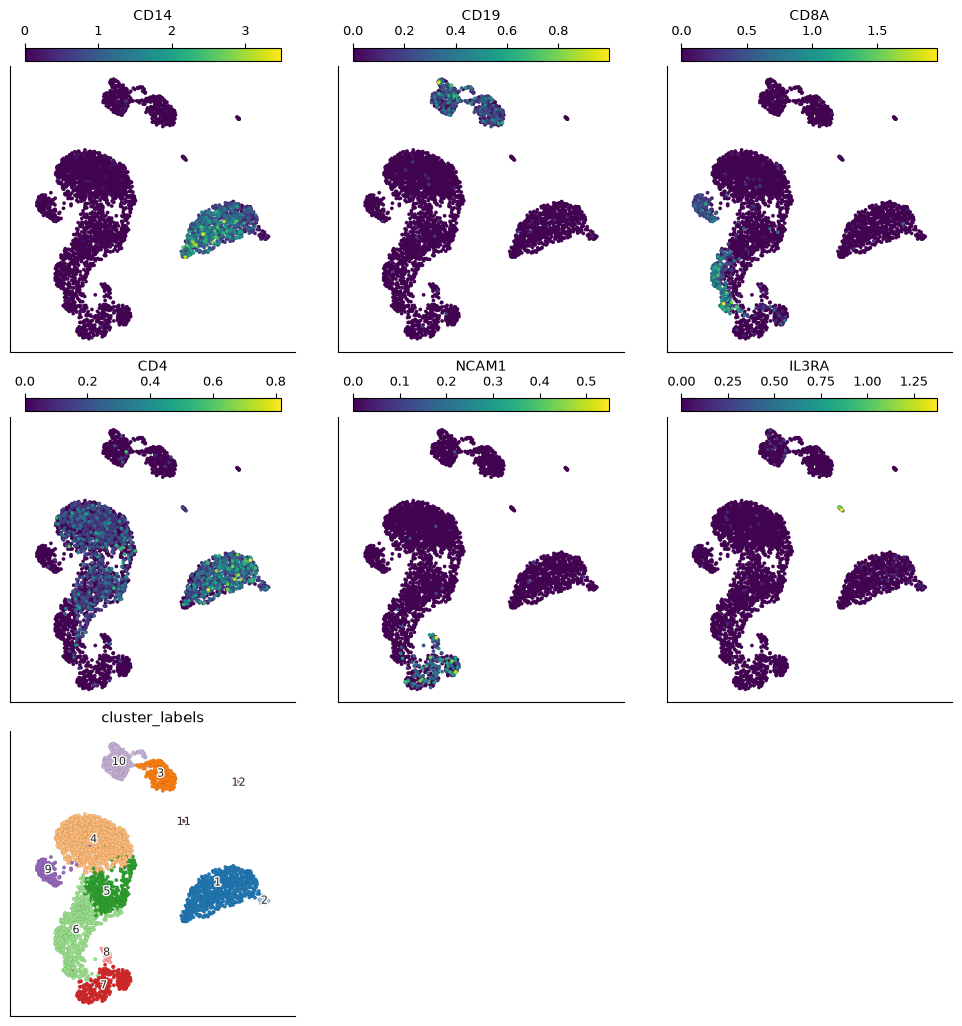

In [3]:
ds.plots.embedding(
    layout=run["umap"],
    color_by=["CD14", "CD19", "CD8A", "CD4", "NCAM1", "IL3RA", clusters],
    n_columns=3,
    sort_values=True,
    legend_loc="on_data"
)

In [4]:
panel_genes = ["CD14", "CD19", "CD8A", "CD4", "NCAM1", "IL3RA"]
panel_markers = ds.get_markers(marker=markers, min_score=-1, min_frac_exp=-1)
panel_stats = panel_markers[panel_markers["feature_name"].isin(panel_genes)]
panel_best = (
    panel_stats.sort_values("score", ascending=False)
    .groupby("feature_name", sort=False)
    .head(1)
    .set_index("feature_name")
    .reindex(panel_genes)[["group_id", "score", "frac_exp", "auc"]]
    .round(2)
    .reset_index()
)
panel_best

,feature_name,group_id,score,frac_exp,auc
0,CD14,1,0.91,0.97,0.98
1,CD19,10,0.52,0.60,0.78
2,CD8A,9,0.50,0.87,0.88
3,CD4,1,0.33,0.76,0.77
4,NCAM1,8,0.52,0.66,0.81
5,IL3RA,11,0.79,1.00,1.00


In [5]:
proposed_labels = {
    "1": "CD14 monocytes",
    "2": "monocytes",
    "3": "B cells",
    "4": "T cells",
    "5": "T cells",
    "6": "T cells",
    "7": "NK cells",
    "8": "NK cells",
    "9": "T cells",
    "10": "B cells",
    "11": "pDC-like cells",
    "12": "unresolved",
}
pd.Series(proposed_labels, name="proposed_cell_type")
assert set(proposed_labels) == {str(value) for value in np.unique(cluster_values)}

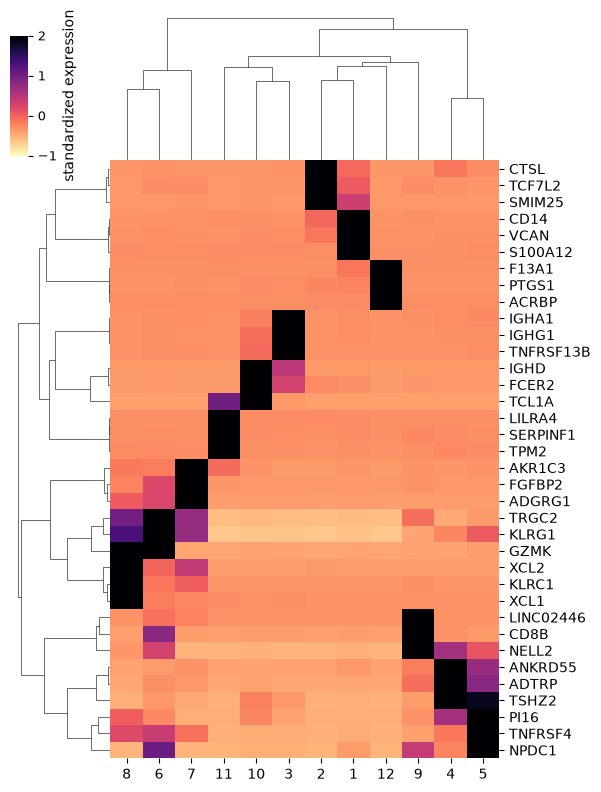

In [6]:
ds.plots.marker_heatmap(
    marker=markers,
    topn=3,
    figsize=(6, 8),
)

In [7]:
heatmap_genes = [
    "CD14", "VCAN", "S100A12", "CTSL", "TCF7L2", "SMIM25", "FCER2", "IGHD",
    "IGHA1", "IGHG1", "TNFRSF13B", "KLRF1", "FGFBP2", "GNLY", "XCL1", "XCL2",
    "KLRC1", "GZMK", "TRGC2", "KLRG1", "CD8A",
    "CD8B", "CD3D", "CD3E", "ADTRP", "ANKRD55", "TSHZ2", "TNFRSF4", "NPDC1",
    "PI16", "NKG7", "TCL1A", "NELL2", "LILRA4", "IL3RA", "PPBP", "SERPINF1",
    "F13A1", "PTGS1", "ADGRG1", "AKR1C3", "CCR7", "IL7R", "CD27",
]
heatmap_markers = ds.get_markers(marker=markers, min_score=-1, min_frac_exp=-1)
heatmap_hits = heatmap_markers[heatmap_markers["feature_name"].isin(heatmap_genes)]
heatmap_table = (
    heatmap_hits.sort_values("score", ascending=False)
    .groupby("feature_name", sort=False)
    .head(1)
    .sort_values("score", ascending=False)
)
heatmap_table["proposed_identity"] = (
    heatmap_table["group_id"].astype(str).map(proposed_labels)
)
heatmap_table[["feature_name", "group_id", "score", "frac_exp", "proposed_identity"]]

,feature_name,group_id,score,frac_exp,proposed_identity
0,S100A12,1,0.93899,0.95571,CD14 monocytes
1,VCAN,1,0.91826,0.98286,CD14 monocytes
2,CD14,1,0.91362,0.96857,CD14 monocytes
67076,IGHA1,3,0.84278,0.72500,B cells
67077,TNFRSF13B,3,0.82388,0.73333,B cells
368918,F13A1,12,0.81929,1.00000,unresolved
335380,SERPINF1,11,0.81361,1.00000,pDC-like cells
368920,PTGS1,12,0.80569,1.00000,unresolved
201228,FGFBP2,7,0.79219,0.99647,NK cells
335382,LILRA4,11,0.78771,1.00000,pDC-like cells


In [8]:
neg_genes = ["CD3D", "CD3E", "CD4", "MS4A1", "CD14"]
neg_markers = ds.get_markers(marker=markers, min_score=-1, min_frac_exp=-1)
neg_stats = neg_markers[neg_markers["feature_name"].isin(neg_genes)]
neg_stats[["group_id", "feature_name", "score", "frac_exp", "auc"]].sort_values(
    ["feature_name", "group_id"]
)

,group_id,feature_name,score,frac_exp,auc
2,1,CD14,0.91362,0.96857,0.98354
335201,10,CD14,0.00714,0.02703,0.41254
368382,11,CD14,0.00383,0.06667,0.43380
399135,12,CD14,0.00240,0.00000,0.40650
61570,2,CD14,0.04743,0.32000,0.54196
100483,3,CD14,0.00371,0.01667,0.40812
134019,4,CD14,0.00427,0.01694,0.37444
167629,5,CD14,0.00288,0.00484,0.39815
201180,6,CD14,0.00317,0.01033,0.39572
234650,7,CD14,0.00450,0.01767,0.40757


In [9]:
anchor_genes = ["NKG7", "GNLY", "KLRF1", "FGFBP2", "CD8A", "CD8B"]
anchor_markers = ds.get_markers(marker=markers, min_score=-1, min_frac_exp=-1)
anchor_stats = anchor_markers[anchor_markers["feature_name"].isin(anchor_genes)]
anchor_stats[["group_id", "feature_name", "score", "frac_exp", "auc"]].sort_values(
    ["feature_name", "group_id"]
)

,group_id,feature_name,score,frac_exp,auc
33309,1,CD8A,0.00624,0.01143,0.43857
335312,10,CD8A,0.00405,0.00772,0.44397
368223,11,CD8A,0.00517,0.06667,0.47380
398651,12,CD8A,0.00323,0.00000,0.44398
66740,2,CD8A,0.00323,0.00000,0.44379
...,...,...,...,...,...
167468,5,NKG7,0.00760,0.10412,0.39627
167813,6,NKG7,0.19532,0.80207,0.81175
201286,7,NKG7,0.40863,1.00000,0.99056
234847,8,NKG7,0.30602,1.00000,0.90223


In [10]:
guard_markers = ds.get_markers(marker=markers, min_score=-1, min_frac_exp=-1)
best_cluster = (
    guard_markers[guard_markers["feature_name"].isin(
        ["NKG7", "GNLY", "KLRF1", "FGFBP2", "CD8A", "CD8B", "PPBP", "IL3RA",
         "LILRA4", "IGHD", "IGHA1", "CD14", "CDKN1C", "TCF7L2", "MS4A1",
         "CD27", "CCR7", "GZMK", "PRF1"]
    )]
    .sort_values("score", ascending=False)
    .groupby("feature_name", sort=False)
    .head(1)
    .set_index("feature_name")["group_id"]
    .astype(str)
    .to_dict()
)
assert best_cluster["NKG7"] in {"7", "8"}
assert best_cluster["GNLY"] in {"7", "8"}
assert best_cluster["KLRF1"] in {"7", "8"}
assert best_cluster["FGFBP2"] == "7"
assert best_cluster["CD8A"] == "9"
assert best_cluster["CD8B"] == "9"
assert best_cluster["CD27"] == "9"
assert best_cluster["CCR7"] in {"4", "9"}
assert best_cluster["GZMK"] in {"6", "8"}
assert best_cluster["PRF1"] == "7"
assert best_cluster["PPBP"] == "12"
assert best_cluster["IL3RA"] == "11"
assert best_cluster["LILRA4"] == "11"
assert best_cluster["IGHD"] == "10"
assert best_cluster["IGHA1"] == "3"
assert best_cluster["CD14"] == "1"
assert best_cluster["CDKN1C"] == "2"
assert best_cluster["TCF7L2"] == "2"
assert best_cluster["MS4A1"] in {"3", "10"}
best_cluster

{'CD14': '1',
 'IGHA1': '3',
 'FGFBP2': '7',
 'LILRA4': '11',
 'IL3RA': '11',
 'IGHD': '10',
 'TCF7L2': '2',
 'CDKN1C': '2',
 'PPBP': '12',
 'CD8B': '9',
 'PRF1': '7',
 'CD8A': '9',
 'GZMK': '8',
 'MS4A1': '3',
 'KLRF1': '8',
 'GNLY': '8',
 'NKG7': '7',
 'CCR7': '4',
 'CD27': '9'}

In [11]:
final_labels = {
    "1": "CD14 monocytes",
    "2": "monocytes",
    "3": "memory B cells",
    "4": "T cells",
    "5": "CD4+ T cells",
    "6": "CD8+ T cells",
    "7": "NK cells",
    "8": "NK cells",
    "9": "naive CD8 T cells",
    "10": "naive B cells",
    "11": "pDC-like cells",
    "12": "Platelets",
}
observed = {str(value) for value in np.unique(cluster_values)}
assert observed == set(final_labels)

analysis_cells = np.asarray(run.cells.fetch_all("I"), dtype=bool)
cell_type = np.full(len(analysis_cells), "Not analyzed", dtype=object)
cell_type[analysis_cells] = [final_labels[str(value)] for value in cluster_values]
ds.cells.insert("reviewed_cell_type", cell_type, overwrite=True)
pd.Series(cell_type[analysis_cells]).value_counts()

T cells              1240
CD14 monocytes        700
CD8+ T cells          581
CD4+ T cells          413
NK cells              312
naive B cells         259
memory B cells        240
naive CD8 T cells     151
monocytes              25
pDC-like cells         15
Platelets              12
Name: count, dtype: int64

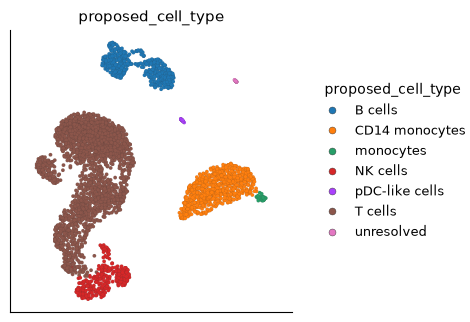

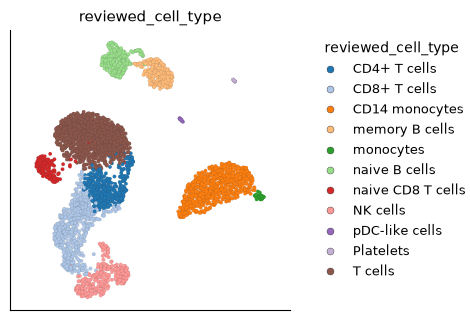

In [12]:
initial_cell_type = np.full(len(analysis_cells), "Not analyzed", dtype=object)
initial_cell_type[analysis_cells] = [proposed_labels[str(value)] for value in cluster_values]
ds.cells.insert("proposed_cell_type", initial_cell_type, overwrite=True)
ds.plots.embedding(
    layout=run["umap"],
    color_by="proposed_cell_type",
    legend_loc="right",
)

ds.plots.embedding(
    layout=run["umap"],
    color_by="reviewed_cell_type",
    legend_loc="right",
)